# 스타티(Startie) 채널 분석 (발표자료 2부)
분석 기간: **2025-03-01 ~ 2025-05-31 (signup_date 기준)**


## Step 1. 채널별 유입 규모 확인

### 코드 블록 설명
- 목적: 채널별 유입량의 분포와 비중을 파악합니다.
- 계산: 채널별 `signups`, 전체 대비 `share_pct`
- 산출물: 유입 규모 표 + 채널별 가입자 수 막대그래프



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib import font_manager

u = pd.read_csv('data/users.csv', parse_dates=['signup_date']).query("signup_date >= '2025-03-01' and signup_date <= '2025-05-31'").copy()
font_candidates = ['NanumGothic', 'Malgun Gothic', 'AppleGothic']
installed = {f.name for f in font_manager.fontManager.ttflist}
for f in font_candidates:
    if f in installed:
        plt.rcParams['font.family'] = f
        break
plt.rcParams['axes.unicode_minus'] = False

step1_df = (
    u.groupby('acquisition_source', as_index=False)
     .agg(signups=('user_id', 'count'))
     .sort_values('signups', ascending=False)
)
step1_df['share_pct'] = (step1_df['signups'] / step1_df['signups'].sum() * 100).round(1)

styled = step1_df.style.format({'signups': '{:,.0f}', 'share_pct': '{:.1f}%'}).highlight_max(subset=['signups'], color='#fff2cc')
display(styled)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(step1_df['acquisition_source'], step1_df['signups'], color='#4e79a7')
for b, pct in zip(bars, step1_df['share_pct']):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{pct:.1f}%", ha='center', va='bottom', fontsize=9)
ax.set_title('Step 1. 채널별 신규 가입자 수')
ax.set_xlabel('채널')
ax.set_ylabel('가입자 수')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

top3 = step1_df.head(3)
print('Top3 유입 채널:', ', '.join(top3['acquisition_source']))
# 인사이트: 유입 규모는 채널별 편차가 크며, 볼륨만으로는 예산 우선순위를 결정하기 어렵다.
# 인사이트: 다음 단계에서 유료전환율로 채널 품질을 검증한다.




## Step 2. 채널별 유료전환율 분석 (메인 KPI)

### 코드 블록 설명
- 목적: 채널별 유료 전환 효율을 비교합니다.
- 계산: `paid_conversion_pct = paid_users / signups`
- 산출물: 전환율 표 + 채널별 유료전환율 그래프



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib import font_manager

u = pd.read_csv('data/users.csv', parse_dates=['signup_date']).query("signup_date >= '2025-03-01' and signup_date <= '2025-05-31'").copy()
plan = pd.read_csv('data/plan_history.csv', parse_dates=['action_date'])
font_candidates = ['NanumGothic', 'Malgun Gothic', 'AppleGothic']
installed = {f.name for f in font_manager.fontManager.ttflist}
for f in font_candidates:
    if f in installed:
        plt.rcParams['font.family'] = f
        break
plt.rcParams['axes.unicode_minus'] = False

paid_users = set(plan.loc[plan['action'] == 'subscribe', 'user_id'])
u['is_paid'] = u['user_id'].isin(paid_users)

step2_df = (
    u.groupby('acquisition_source', as_index=False)
     .agg(signups=('user_id', 'count'), paid_users=('is_paid', 'sum'))
)
step2_df['paid_conversion_pct'] = (step2_df['paid_users'] / step2_df['signups'] * 100).round(1)
step2_df = step2_df.sort_values('paid_conversion_pct', ascending=False)

styled = step2_df.style.format({
    'signups':'{:,.0f}',
    'paid_users':'{:,.0f}',
    'paid_conversion_pct':'{:.1f}%'
}).highlight_max(subset=['paid_conversion_pct'], color='#d9ead3')   .highlight_min(subset=['paid_conversion_pct'], color='#f4cccc')
display(styled)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(step2_df['acquisition_source'][::-1], step2_df['paid_conversion_pct'][::-1], color='#59a14f')
ax.set_title('Step 2. 채널별 유료전환율')
ax.set_xlabel('유료전환율(%)')
plt.tight_layout()
plt.show()

print('유료전환율 상위 채널:', step2_df.iloc[0]['acquisition_source'])
print('유료전환율 하위 채널:', step2_df.iloc[-1]['acquisition_source'])
# 인사이트: 본 분석의 메인 KPI는 유료전환율이며, 채널 확장/축소 판단의 1차 기준으로 사용한다.




## Step 3. 채널별 매출액 vs 유료전환율

### 코드 블록 설명
- 목적: 채널별 매출 기여와 전환 효율을 동시에 비교합니다.
- 계산: 결제 완료 금액 기준 `revenue`, `revenue_share_pct`, `paid_conversion_pct`
- 산출물: 매출 막대그래프, 전환율 꺾은선그래프, 통합 그래프



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib import font_manager

# Step 2 결과가 없으면 복구 계산
if 'step2_df' not in globals():
    u = pd.read_csv('data/users.csv', parse_dates=['signup_date']).query("signup_date >= '2025-03-01' and signup_date <= '2025-05-31'").copy()
    plan = pd.read_csv('data/plan_history.csv', parse_dates=['action_date'])
    paid_users = set(plan.loc[plan['action'] == 'subscribe', 'user_id'])
    u['is_paid'] = u['user_id'].isin(paid_users)

    step2_df = (
        u.groupby('acquisition_source', as_index=False)
         .agg(signups=('user_id', 'count'), paid_users=('is_paid', 'sum'))
    )
    step2_df['paid_conversion_pct'] = (step2_df['paid_users'] / step2_df['signups'] * 100).round(1)

u = pd.read_csv('data/users.csv', parse_dates=['signup_date']).query("signup_date >= '2025-03-01' and signup_date <= '2025-05-31'").copy()
pay = pd.read_csv('data/payment_transactions.csv', parse_dates=['transaction_date'])

font_candidates = ['NanumGothic', 'Malgun Gothic', 'AppleGothic']
installed = {f.name for f in font_manager.fontManager.ttflist}
for f in font_candidates:
    if f in installed:
        plt.rcParams['font.family'] = f
        break
plt.rcParams['axes.unicode_minus'] = False

rev_user = (
    pay.loc[pay['status'] == 'completed', ['user_id', 'amount']]
       .groupby('user_id', as_index=False)
       .agg(revenue=('amount', 'sum'))
)

rev_channel = (
    u[['user_id', 'acquisition_source']]
    .merge(rev_user, on='user_id', how='left')
    .fillna({'revenue': 0})
    .groupby('acquisition_source', as_index=False)
    .agg(revenue=('revenue', 'sum'))
)

step3_df = (
    step2_df[['acquisition_source', 'signups', 'paid_users', 'paid_conversion_pct']]
    .merge(rev_channel, on='acquisition_source', how='left')
    .fillna({'revenue': 0})
)
step3_df['revenue_share_pct'] = (step3_df['revenue'] / step3_df['revenue'].sum() * 100).round(1)
step3_df['arpu'] = (step3_df['revenue'] / step3_df['signups']).round(1)
step3_df = step3_df.sort_values('revenue', ascending=False).reset_index(drop=True)

styled = step3_df.style.format({
    'signups': '{:,.0f}',
    'paid_users': '{:,.0f}',
    'paid_conversion_pct': '{:.1f}%',
    'revenue': '{:,.0f}',
    'revenue_share_pct': '{:.1f}%',
    'arpu': '{:,.1f}'
}).highlight_max(subset=['revenue', 'paid_conversion_pct', 'revenue_share_pct'], color='#d9ead3')
display(styled)

plot_df = step3_df.copy()
labels = plot_df['acquisition_source']
x = np.arange(len(labels))

# 1) 매출액 단독 막대그래프
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(x, plot_df['revenue'], color='#4e79a7', alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20)
ax.set_title('Step 3-1. 채널별 매출액')
ax.set_ylabel('매출액')
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{b.get_height():,.0f}", ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

# 2) 유료전환율 단독 꺾은선그래프
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(x, plot_df['paid_conversion_pct'], color='#e15759', marker='o', linewidth=2.5)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20)
ax.set_title('Step 3-2. 채널별 유료전환율')
ax.set_ylabel('유료전환율(%)')
for xi, yi in zip(x, plot_df['paid_conversion_pct']):
    ax.text(xi, yi + 0.5, f"{yi:.1f}%", ha='center', va='bottom', fontsize=9)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

# 3) 합친 그래프 (막대=매출액, 꺾은선=유료전환율)
fig, ax1 = plt.subplots(figsize=(12, 5.5))
bar = ax1.bar(x, plot_df['revenue'], color='#4e79a7', alpha=0.75, label='매출액')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=20)
ax1.set_ylabel('매출액', color='#4e79a7')
ax1.tick_params(axis='y', labelcolor='#4e79a7')

ax2 = ax1.twinx()
line = ax2.plot(x, plot_df['paid_conversion_pct'], color='#e15759', marker='o', linewidth=2.5, label='유료전환율(%)')
ax2.set_ylabel('유료전환율(%)', color='#e15759')
ax2.tick_params(axis='y', labelcolor='#e15759')

for xi, yi in zip(x, plot_df['paid_conversion_pct']):
    ax2.text(xi, yi + 0.5, f"{yi:.1f}%", ha='center', va='bottom', fontsize=9, color='#e15759')

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper right')
ax1.set_title('Step 3-3. 채널별 매출액 vs 유료전환율 (통합)')
plt.tight_layout()
plt.show()

rev_mean = step3_df['revenue'].mean()
conv_mean = step3_df['paid_conversion_pct'].mean()
expand = step3_df[(step3_df['revenue'] >= rev_mean) & (step3_df['paid_conversion_pct'] >= conv_mean)]
improve = step3_df[(step3_df['revenue'] >= rev_mean) & (step3_df['paid_conversion_pct'] < conv_mean)]

print('확장 우선(매출↑·전환↑):', ', '.join(expand['acquisition_source']) if len(expand) else '없음')
print('전환 개선 우선(매출↑·전환↓):', ', '.join(improve['acquisition_source']) if len(improve) else '없음')
# 인사이트: Step 3 의사결정은 유료전환율 단일 지표가 아니라 채널별 매출 기여와 함께 판단해야 우선순위가 명확해진다.




## Step 4. 채널별 D7/D30 리텐션

### 코드 블록 설명
- 목적: 채널별 단기(D7)·중기(D30) 유지력을 확인합니다.
- 계산: 가입 후 1~7일, 15~30일 이벤트 발생 여부로 리텐션율 산출
- 산출물: D7/D30 리텐션 표 + 이중 막대그래프(수치 라벨 포함)



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib import font_manager

u = pd.read_csv('data/users.csv', parse_dates=['signup_date']).query("signup_date >= '2025-03-01' and signup_date <= '2025-05-31'").copy()
events = pd.read_csv('data/event_logs.csv', parse_dates=['event_timestamp'])
font_candidates = ['NanumGothic', 'Malgun Gothic', 'AppleGothic']
installed = {f.name for f in font_manager.fontManager.ttflist}
for f in font_candidates:
    if f in installed:
        plt.rcParams['font.family'] = f
        break
plt.rcParams['axes.unicode_minus'] = False

ev = events.merge(u[['user_id', 'signup_date', 'acquisition_source']], on='user_id', how='inner')
ev['event_date'] = ev['event_timestamp'].dt.normalize()
ev['gap_days'] = (ev['event_date'] - ev['signup_date']).dt.days

u['ret_d7'] = u['user_id'].isin(ev.loc[ev['gap_days'].between(1, 7), 'user_id'])
u['ret_d30'] = u['user_id'].isin(ev.loc[ev['gap_days'].between(15, 30), 'user_id'])

step4_df = (
    u.groupby('acquisition_source', as_index=False)
     .agg(signups=('user_id', 'count'), d7_users=('ret_d7', 'sum'), d30_users=('ret_d30', 'sum'))
)
step4_df['d7_retention_pct'] = (step4_df['d7_users'] / step4_df['signups'] * 100).round(1)
step4_df['d30_retention_pct'] = (step4_df['d30_users'] / step4_df['signups'] * 100).round(1)
step4_df = step4_df.sort_values('d30_retention_pct', ascending=False)

display(step4_df[['acquisition_source', 'd7_retention_pct', 'd30_retention_pct']].style.format({'d7_retention_pct':'{:.1f}%','d30_retention_pct':'{:.1f}%'}).highlight_max(subset=['d30_retention_pct'], color='#d9ead3'))

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(step4_df))
w = 0.35
bars1 = ax.bar(x - w/2, step4_df['d7_retention_pct'], width=w, label='D7')
bars2 = ax.bar(x + w/2, step4_df['d30_retention_pct'], width=w, label='D30')
for b in bars1:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, h, f'{h:.1f}%', ha='center', va='bottom', fontsize=8)
for b in bars2:
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, h, f'{h:.1f}%', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(step4_df['acquisition_source'], rotation=20)
ax.set_ylabel('리텐션(%)')
ax.set_title('Step 4. 채널별 D7/D30 리텐션')
ax.legend()
plt.tight_layout()
plt.show()

# 인사이트: D30 리텐션 상위 채널과 유입 상위 채널이 다르면, 양적 확대보다 질적 채널 최적화가 유효하다.
# 인사이트: 장기 잔존(D30) 우위 채널은 LTV 개선의 선행지표로 해석할 수 있다.



## Step 5. 종합 스코어링 모델 A (ROI 포함)

### 코드 블록 설명
- 목적: 비용 효율(ROI)을 포함한 기준으로 상위 채널을 선정합니다.
- 계산: `final_score_roi = 0.40*ROI + 0.30*CVR + 0.15*ARPU + 0.15*Retention`
- 산출물: 최종 스코어 표, 등급표, TOP2 시각화



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib import font_manager

# 분석 기간 코호트
start_dt = pd.Timestamp('2025-03-01')
end_dt = pd.Timestamp('2025-05-31')
users = pd.read_csv('data/users.csv', parse_dates=['signup_date'])
payments = pd.read_csv('data/payment_transactions.csv', parse_dates=['transaction_date'])
campaigns = pd.read_csv('data/campaigns.csv', parse_dates=['start_date', 'end_date'])
events = pd.read_csv('data/event_logs.csv', parse_dates=['event_timestamp'])

font_candidates = ['NanumGothic', 'Malgun Gothic', 'AppleGothic']
installed = {f.name for f in font_manager.fontManager.ttflist}
for f in font_candidates:
    if f in installed:
        plt.rcParams['font.family'] = f
        break
plt.rcParams['axes.unicode_minus'] = False

cohort = users[(users['signup_date'] >= start_dt) & (users['signup_date'] <= end_dt)].copy()
cohort_ids = cohort['user_id'].unique()

# CVR + ARPU (completed 결제 기준)
paid = payments[(payments['user_id'].isin(cohort_ids)) & (payments['status'] == 'completed')]
revenue = paid.groupby('user_id')['amount'].sum().reset_index()
merged = pd.merge(cohort[['user_id', 'acquisition_source', 'signup_date']], revenue, on='user_id', how='left').fillna(0)
merged['is_paid'] = merged['amount'] > 0

ch = merged.groupby('acquisition_source').agg(
    user_count=('user_id', 'count'),
    paid_count=('is_paid', 'sum'),
    cvr=('is_paid', 'mean'),
    arpu=('amount', 'mean')
).reset_index()

# LTV/CAC (Channel_Value_Analysis 기준)
camps = campaigns.copy()
camps['p_end'] = camps['end_date'].fillna(end_dt)

def get_spend(row):
    s = max(row['start_date'], start_dt)
    e = min(row['p_end'], end_dt)
    days = max(0, (e - s).days + 1)
    return days * row['daily_budget']

camps['spend'] = camps.apply(get_spend, axis=1)
spend_by_ch = camps.groupby('channel')['spend'].sum().reset_index()

ch = pd.merge(ch, spend_by_ch, left_on='acquisition_source', right_on='channel', how='left').fillna(0)
ch['cac'] = ch.apply(lambda r: r['spend'] / r['user_count'] if r['user_count'] > 0 else 0, axis=1)
ch['ltv_cac'] = ch.apply(lambda r: r['arpu'] / r['cac'] if r['cac'] > 0 else np.nan, axis=1)

# D7/D30 Bracket 리텐션
ev = events[events['user_id'].isin(cohort_ids)].merge(
    cohort[['user_id', 'signup_date', 'acquisition_source']], on='user_id'
)
ev['gap_days'] = (ev['event_timestamp'].dt.normalize() - ev['signup_date'].dt.normalize()).dt.days
d7_ids = ev[(ev['gap_days'] >= 1) & (ev['gap_days'] <= 7)]['user_id'].unique()
d30_ids = ev[(ev['gap_days'] >= 15) & (ev['gap_days'] <= 30)]['user_id'].unique()
merged['d7'] = merged['user_id'].isin(d7_ids)
merged['d30'] = merged['user_id'].isin(d30_ids)

ret = merged.groupby('acquisition_source').agg(
    d7_rate=('d7', 'mean'),
    d30_rate=('d30', 'mean')
).reset_index()

# 스코어 컴포넌트
base_df = pd.merge(ch, ret, on='acquisition_source')

def norm(s):
    if s.max() == s.min():
        return pd.Series([100] * len(s), index=s.index)
    return (s - s.min()) / (s.max() - s.min()) * 100

def to_grade(x):
    if x >= 85:
        return 'S'
    if x >= 70:
        return 'A'
    if x >= 55:
        return 'B'
    if x >= 40:
        return 'C'
    return 'D'

base_df['ltv_cac_filled'] = base_df['ltv_cac'].fillna(base_df['ltv_cac'].max())
base_df['s_roi'] = norm(base_df['ltv_cac_filled'])
base_df['s_cvr'] = norm(base_df['cvr'])
base_df['s_arpu'] = norm(base_df['arpu'])
base_df['s_ret'] = norm(base_df['d7_rate'] + base_df['d30_rate'])

# 모델 A(ROI 포함)
base_df['final_score_roi'] = (
    base_df['s_roi'] * 0.40 +
    base_df['s_cvr'] * 0.30 +
    base_df['s_arpu'] * 0.15 +
    base_df['s_ret'] * 0.15
)
roi_df = base_df.sort_values('final_score_roi', ascending=False).reset_index(drop=True)

print('=== [모델 A] 최종 종합 스코어 (ROI 포함) ===')
display(
    roi_df[['acquisition_source', 'cvr', 'arpu', 'ltv_cac', 'd7_rate', 'd30_rate', 'final_score_roi']]
    .rename(columns={'final_score_roi':'final_score'})
    .style
    .format({'cvr':'{:.1%}', 'arpu':'{:,.1f}', 'ltv_cac':'{:.2f}', 'd7_rate':'{:.1%}', 'd30_rate':'{:.1%}', 'final_score':'{:.1f}'})
    .highlight_max(subset=['final_score'], color='#d9ead3')
)

roi_grade = roi_df[['acquisition_source', 'final_score_roi']].copy()
roi_grade['grade'] = roi_grade['final_score_roi'].apply(to_grade)
print('=== [모델 A] 등급표 ===')
display(roi_grade.rename(columns={'acquisition_source':'채널','final_score_roi':'종합점수','grade':'등급'}).style.format({'종합점수':'{:.1f}'}))

fig, ax = plt.subplots(figsize=(10.5, 5))
colors = ['#e15759' if i < 2 else '#9aa0a6' for i in range(len(roi_df))]
bars = ax.bar(roi_df['acquisition_source'], roi_df['final_score_roi'], color=colors)
for i, b in enumerate(bars):
    ax.text(b.get_x() + b.get_width()/2, b.get_height(), f"{b.get_height():.1f}", ha='center', va='bottom', fontsize=9)
    if i < 2:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1.8, f"TOP {i+1}", ha='center', va='bottom', fontsize=9, color='#e15759', fontweight='bold')
ax.set_title('Step 5. 모델 A 최종 종합 스코어 (ROI 포함)')
ax.set_ylabel('점수')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

print('[모델 A] 상위 2채널:', ', '.join(roi_df.head(2)['acquisition_source']))




## Step 6. 연령대 × 채널 전환율

### 코드 블록 설명
- 목적: 연령대와 채널의 조합별 전환율 차이를 찾습니다.
- 계산: `age_group × acquisition_source` 전환율 피벗
- 산출물: 히트맵 + 최고 조합 출력



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib import font_manager

u = pd.read_csv('data/users.csv', parse_dates=['signup_date']).query("signup_date >= '2025-03-01' and signup_date <= '2025-05-31'").copy()
plan = pd.read_csv('data/plan_history.csv', parse_dates=['action_date'])
font_candidates = ['NanumGothic', 'Malgun Gothic', 'AppleGothic']
installed = {f.name for f in font_manager.fontManager.ttflist}
for f in font_candidates:
    if f in installed:
        plt.rcParams['font.family'] = f
        break
plt.rcParams['axes.unicode_minus'] = False

paid_users = set(plan.loc[plan['action'] == 'subscribe', 'user_id'])
u['is_paid'] = u['user_id'].isin(paid_users)

tmp = u.groupby(['age_group', 'acquisition_source'], as_index=False).agg(signups=('user_id', 'count'), paid_users=('is_paid', 'sum'))
tmp['paid_conversion_pct'] = (tmp['paid_users'] / tmp['signups'] * 100).round(1)
pivot6 = tmp.pivot(index='age_group', columns='acquisition_source', values='paid_conversion_pct').fillna(0)

display(pivot6.style.format('{:.1f}%').highlight_max(axis=None, color='#d9ead3'))

plt.figure(figsize=(11, 5))
sns.heatmap(
    pivot6,
    annot=True,
    fmt='.1f',
    cmap='YlGn',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': '전환율(%)'}
)
plt.title('Step 6. 연령대 × 채널 전환율 히트맵')
plt.xlabel('채널', fontsize=11, labelpad=8)
plt.ylabel('연령대', fontsize=11, labelpad=8)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

best = tmp.loc[tmp['paid_conversion_pct'].idxmax(), ['age_group', 'acquisition_source', 'paid_conversion_pct']]
print(f"최고 조합: {best['age_group']} + {best['acquisition_source']} ({best['paid_conversion_pct']:.1f}%)")
# 인사이트: 특정 연령대-채널 조합에서 전환율이 집중되므로 연령 타겟팅이 CAC 절감에 직접 기여한다.
# 인사이트: 최고 전환 조합은 크리에이티브/메시지 맞춤 집행의 1순위 세그먼트다.



## Step 7. 디바이스 × 채널 전환율

### 코드 블록 설명
- 목적: 디바이스별 채널 성과 차이를 확인합니다.
- 계산: `device_type × acquisition_source` 전환율 비교
- 산출물: 그룹 막대그래프 + 우선 타겟 디바이스 출력



acquisition_source,content_marketing,google_ads,instagram_influencer,meta_ads,organic,referral,youtube
device_type,,,,,,,
android,16.0%,22.4%,12.2%,13.5%,16.0%,23.0%,20.0%
ios,21.0%,28.5%,17.2%,14.0%,23.9%,30.8%,25.7%
web,25.9%,37.5%,26.8%,22.8%,28.0%,40.3%,36.4%


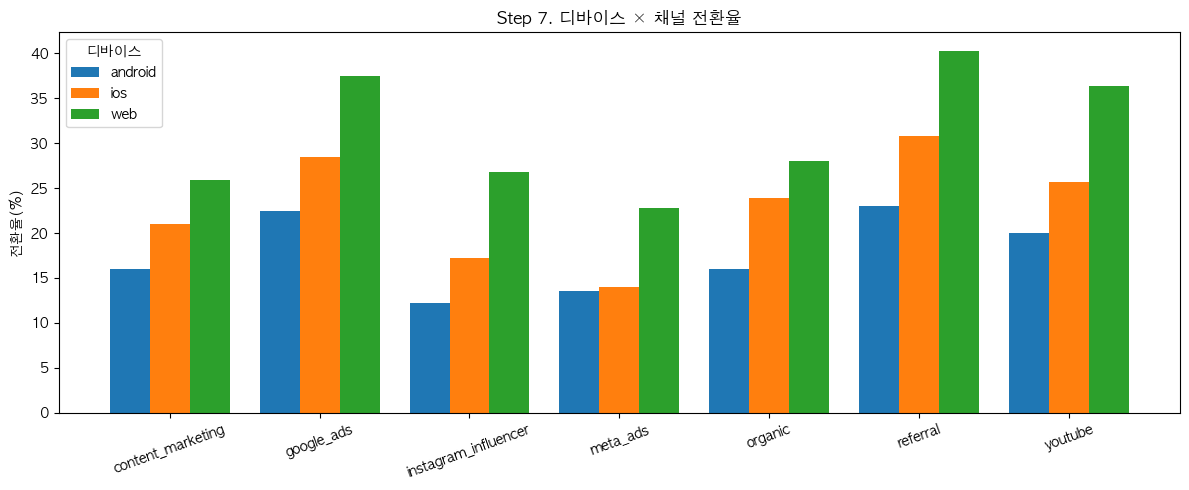

우선 디바이스 타겟: web (평균 전환율 31.1%)


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib import font_manager

u = pd.read_csv('data/users.csv', parse_dates=['signup_date']).query("signup_date >= '2025-03-01' and signup_date <= '2025-05-31'").copy()
plan = pd.read_csv('data/plan_history.csv', parse_dates=['action_date'])
font_candidates = ['NanumGothic', 'Malgun Gothic', 'AppleGothic']
installed = {f.name for f in font_manager.fontManager.ttflist}
for f in font_candidates:
    if f in installed:
        plt.rcParams['font.family'] = f
        break
plt.rcParams['axes.unicode_minus'] = False

paid_users = set(plan.loc[plan['action'] == 'subscribe', 'user_id'])
u['is_paid'] = u['user_id'].isin(paid_users)

tmp = u.groupby(['device_type', 'acquisition_source'], as_index=False).agg(signups=('user_id', 'count'), paid_users=('is_paid', 'sum'))
tmp['paid_conversion_pct'] = (tmp['paid_users'] / tmp['signups'] * 100).round(1)
pivot7 = tmp.pivot(index='device_type', columns='acquisition_source', values='paid_conversion_pct').fillna(0)

display(pivot7.style.format('{:.1f}%').highlight_max(axis=0, color='#d9ead3'))

channels = pivot7.columns.tolist()
devices = pivot7.index.tolist()
x = np.arange(len(channels))
w = 0.8 / len(devices)
fig, ax = plt.subplots(figsize=(12, 5))
for i, dev in enumerate(devices):
    ax.bar(x + (i - (len(devices)-1)/2) * w, pivot7.loc[dev].values, width=w, label=dev)
ax.set_xticks(x)
ax.set_xticklabels(channels, rotation=20)
ax.set_ylabel('전환율(%)')
ax.set_title('Step 7. 디바이스 × 채널 전환율')
ax.legend(title='디바이스')
plt.tight_layout()
plt.show()

best_device = tmp.groupby('device_type', as_index=False)['paid_conversion_pct'].mean().sort_values('paid_conversion_pct', ascending=False).iloc[0]
print(f"우선 디바이스 타겟: {best_device['device_type']} (평균 전환율 {best_device['paid_conversion_pct']:.1f}%)")
# 인사이트: 디바이스별 전환율 격차가 뚜렷하면 입찰/소재를 디바이스 단위로 분리해야 효율이 오른다.
# 인사이트: 평균 전환율이 가장 높은 디바이스를 광고 기본 타겟으로 우선 배치하는 전략이 유효하다.


## Step 8. Step 5 모델A 기반 실행 세그먼트 도출

### 코드 블록 설명
- 목적: Step 5 모델A 상위 채널을 실행 가능한 코호트(연령대×디바이스) 단위로 분해합니다.
- 입력: Step 5 모델A 채널 점수(`roi_df`), Step 6/7에서 사용한 코호트 축(연령대, 디바이스), 결제/전환 데이터
- 산출: 채널별 코호트 점수 및 우선 실행 타겟

### 결과 설명
- 이 단계는 "어떤 채널이 좋은가"를 넘어 "그 채널에서 누구에게 집행할 것인가"를 정합니다.
- 따라서 Step 9 실행안(예산 재배분/타겟 운영)의 직접 근거가 됩니다.



## Step 8-1. 모델A Top3 채널 선정 및 코호트 점수 계산

### 코드 블록 설명
- 모델A(`roi_df`) 기준 상위 3개 채널을 고정 선정합니다.
- 각 코호트(채널×연령대×디바이스)에 대해 전환율/ARPU를 계산하고,
  채널 우선순위 점수와 결합해 `score_8`(실행 우선점수)를 만듭니다.
- 점수식: `채널우선(50%) + 코호트전환율(30%) + 코호트ARPU(20%)`

### 결과 설명
- 출력되는 Top3 채널은 Step 5 모델A 결과를 실행 레벨로 연결한 채널입니다.
- 이 점수는 코호트 운영의 1차 필터로 사용됩니다.



In [ ]:
import pandas as pd
import numpy as np

u = pd.read_csv('data/users.csv', parse_dates=['signup_date']).query("signup_date >= '2025-03-01' and signup_date <= '2025-05-31'").copy()
plan = pd.read_csv('data/plan_history.csv', parse_dates=['action_date'])
pay = pd.read_csv('data/payment_transactions.csv', parse_dates=['transaction_date'])

def minmax(s):
    if s.max() == s.min():
        return pd.Series([100] * len(s), index=s.index)
    return (s - s.min()) / (s.max() - s.min()) * 100

# Step5 모델A 상위 3채널 고정 (모델B 제외)
if 'roi_df' in globals() and 'final_score_roi' in roi_df.columns:
    top3_channels = roi_df.head(3)['acquisition_source'].tolist()
else:
    raise RuntimeError('Step 5(모델A) 결과가 필요합니다. 먼저 Step 5를 실행해주세요.')

print('Step 8-1 분석 채널(모델A Top3):', ', '.join(top3_channels))

# 채널 우선순위 점수(모델A)
cs = roi_df[['acquisition_source', 'final_score_roi']].copy()
cs = cs[cs['acquisition_source'].isin(top3_channels)].copy()
cs['channel_priority_score'] = minmax(cs['final_score_roi'])

# Step6/7 기반 코호트 성과(연령×디바이스)
paid_users_plan = set(plan.loc[plan['action'] == 'subscribe', 'user_id'])
u['is_paid'] = u['user_id'].isin(paid_users_plan)

seg = u[u['acquisition_source'].isin(top3_channels)].groupby(
    ['acquisition_source', 'age_group', 'device_type'], as_index=False
).agg(signups=('user_id', 'count'), paid_users=('is_paid', 'sum'))
seg['conversion_pct'] = np.where(seg['signups'] > 0, seg['paid_users'] / seg['signups'], 0)

pay_ok = pay[(pay['status'] == 'completed') & (pay['user_id'].isin(u['user_id']))].copy()
seg_pay = pay_ok.merge(u[['user_id', 'acquisition_source', 'age_group', 'device_type']], on='user_id', how='inner')
seg_rev = seg_pay.groupby(['acquisition_source', 'age_group', 'device_type'], as_index=False).agg(revenue=('amount', 'sum'))
seg = seg.merge(seg_rev, on=['acquisition_source', 'age_group', 'device_type'], how='left').fillna(0)
seg['ARPU'] = np.where(seg['signups'] > 0, seg['revenue'] / seg['signups'], 0)

# 통합 점수: 채널우선(50) + 전환율(30) + ARPU(20)
seg = seg.merge(cs[['acquisition_source', 'channel_priority_score']], on='acquisition_source', how='left')
seg['n_cvr'] = minmax(seg['conversion_pct'])
seg['n_arpu'] = minmax(seg['ARPU'])
seg['score_8'] = seg['channel_priority_score'] * 0.50 + seg['n_cvr'] * 0.30 + seg['n_arpu'] * 0.20
seg = seg.sort_values('score_8', ascending=False).reset_index(drop=True)




## Step 8-2. 채널별 코호트 TOP 5

### 코드 블록 설명
- Step 8-1에서 계산한 `score_8`을 기준으로 채널별 상위 5개 코호트를 출력합니다.
- 채널별로 분리해 보는 이유는 채널 내부 최적 타겟이 서로 다르기 때문입니다.

### 결과 설명
- 각 채널 표의 상위 코호트가 해당 채널의 우선 집행 타겟입니다.
- 채널별로 TOP5를 유지하면 운영 시 타겟 다양성과 안정성을 확보할 수 있습니다.



In [ ]:
from IPython.display import display

if 'seg' not in globals() or 'top3_channels' not in globals():
    raise RuntimeError('Step 8-1을 먼저 실행해주세요.')

print('=== 채널별 코호트 TOP 5 ===')
for ch in top3_channels:
    out = (
        seg[seg['acquisition_source'] == ch][['age_group', 'device_type', 'signups', 'conversion_pct', 'ARPU', 'score_8']]
        .sort_values('score_8', ascending=False)
        .head(5)
        .reset_index(drop=True)
    )
    out.insert(0, 'rank', out.index + 1)

    print(f"\n[{ch}] 코호트 TOP 5")
    styled = (
        out.style
        .format({'signups':'{:,.0f}', 'conversion_pct':'{:.1%}', 'ARPU':'{:,.0f}', 'score_8':'{:.1f}'})
        .background_gradient(subset=['score_8'], cmap='YlGn')
        .background_gradient(subset=['conversion_pct'], cmap='GnBu')
        .set_properties(**{'text-align':'center', 'font-size':'10pt'})
        .set_table_styles([
            {'selector':'th', 'props':'background-color:#f3f7f3; color:#1f2937; text-align:center; font-weight:bold;'},
            {'selector':'td', 'props':'padding:6px;'}
        ])
        .hide(axis='index')
    )
    display(styled)



## Step 8-3. 통합 코호트 결과표 (한 번에 보기)

### 코드 블록 설명
- 채널별 TOP5를 하나의 표로 합쳐 전체 우선순위를 재정렬합니다.
- 채널별 상세표(8-2)와 달리, 실행 순서를 한 번에 확인하기 위한 요약 표입니다.

### 결과 설명
- 표 최상단 코호트가 즉시 실행 1순위입니다.
- 상위 구간 코호트를 중심으로 예산/소재/랜딩 우선 적용 대상을 확정합니다.



In [ ]:
from IPython.display import display

if 'seg' not in globals():
    raise RuntimeError('Step 8-1을 먼저 실행해주세요.')

# 채널별 상위 5개를 합쳐 통합표 생성
seg_top5_by_channel = (
    seg.sort_values('score_8', ascending=False)
       .groupby('acquisition_source', as_index=False)
       .head(5)
       .copy()
)

# 통합표는 점수 기준 재정렬
seg_all_view = (
    seg_top5_by_channel[['acquisition_source', 'age_group', 'device_type', 'signups', 'conversion_pct', 'ARPU', 'score_8']]
    .sort_values('score_8', ascending=False)
    .reset_index(drop=True)
)
seg_all_view.insert(0, 'rank', seg_all_view.index + 1)

print('=== Step 8-3 통합 코호트 결과표 (채널별 TOP5 합본) ===')
styled_all = (
    seg_all_view.style
    .format({'signups':'{:,.0f}', 'conversion_pct':'{:.1%}', 'ARPU':'{:,.0f}', 'score_8':'{:.1f}'})
    .background_gradient(subset=['score_8'], cmap='YlGn')
    .background_gradient(subset=['ARPU'], cmap='GnBu')
    .set_properties(**{'text-align':'center', 'font-size':'10pt'})
    .set_table_styles([
        {'selector':'th', 'props':'background-color:#eef6ee; color:#111827; text-align:center; font-weight:bold;'},
        {'selector':'td', 'props':'padding:6px;'}
    ])
    .hide(axis='index')
)
display(styled_all)

best = seg_all_view.iloc[0]
print('최우선 실행 세그먼트:', f"{best['acquisition_source']} | {best['age_group']} | {best['device_type']}")



## Step 8-4. 시각화

### 코드 블록 설명
- 8-4A: 채널별 최고 코호트 점수 비교(채널 단위 우선순위 확인)
- 8-4B: 통합 코호트 TOP10 랭킹(실행 타겟 순서 확인)

### 결과 설명
- 8-4A는 채널 단위 의사결정(어느 채널에 우선 예산을 둘지)에 유리합니다.
- 8-4B는 코호트 단위 실행계획(어떤 타겟부터 집행할지)에 유리합니다.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager

if 'seg' not in globals() or 'seg_all_view' not in globals():
    raise RuntimeError('Step 8-1~8-3을 먼저 실행해주세요.')

# 한글 폰트 고정(환경별 fallback)
font_candidates = ['NanumGothic', 'Malgun Gothic', 'AppleGothic']
installed = {f.name for f in font_manager.fontManager.ttflist}
for f in font_candidates:
    if f in installed:
        plt.rcParams['font.family'] = f
        break
plt.rcParams['axes.unicode_minus'] = False

# seaborn theme 적용 시 폰트가 덮어씌워지지 않도록 rc로 고정
sns.set_theme(style='whitegrid', font_scale=0.95, rc={'font.family': plt.rcParams['font.family'], 'axes.unicode_minus': False})

# 1) 채널별 최고 코호트 점수
best_by_channel = (
    seg.sort_values('score_8', ascending=False)
       .groupby('acquisition_source', as_index=False)
       .head(1)
       .sort_values('score_8', ascending=False)
)

fig, ax = plt.subplots(figsize=(9.8, 5.2))
palette = ['#2a9d8f', '#66bb6a', '#90caf9']
bars = ax.bar(best_by_channel['acquisition_source'], best_by_channel['score_8'], color=palette[:len(best_by_channel)], width=0.58)

for b, (_, r) in zip(bars, best_by_channel.iterrows()):
    ax.text(
        b.get_x() + b.get_width()/2,
        b.get_height() + 0.7,
        f"{b.get_height():.1f}\n{r['age_group']} | {r['device_type']}",
        ha='center',
        va='bottom',
        fontsize=8,
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='#d1d5db', alpha=0.9)
    )
ax.set_title('Step 8-4A. 채널별 최고 코호트 통합점수', fontsize=12, pad=12)
ax.set_ylabel('코호트 통합점수')
ax.set_xlabel('채널')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

# 2) 통합 TOP10 코호트 랭킹
viz = seg_all_view.head(10).copy()
viz['label'] = viz['acquisition_source'] + ' | ' + viz['age_group'] + ' | ' + viz['device_type']
viz = viz.sort_values('score_8', ascending=True)

fig, ax = plt.subplots(figsize=(12.2, 6.2))
bar_colors = sns.color_palette('YlGn', n_colors=len(viz))
ax.barh(viz['label'], viz['score_8'], color=bar_colors)
for y, s in zip(viz['label'], viz['score_8']):
    ax.text(s + 0.5, y, f"{s:.1f}", va='center', fontsize=8)
ax.set_title('Step 8-4B. 통합 코호트 점수 TOP10', fontsize=12, pad=10)
ax.set_xlabel('통합점수')
ax.set_ylabel('코호트(채널 | 연령대 | 디바이스)')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()




## Step 9. Step 8 기반 최종 실행안 요약

### 코드 블록 설명
- 목적: Step 8 결과를 최종 실행안으로 변환합니다.
- 구성: 9-1(요약표) → 9-2(시각화) → 9-3(최종 권고) → 9-4(채널별 액션 후보)

### 결과 설명
- Step 9는 추가 분석이 아니라 Step 8 결과를 의사결정 문장으로 정리하는 단계입니다.



## Step 9-1. 최종 실행 요약표

### 코드 블록 설명
- Step 8 결과만으로 채널 우선순위와 권장예산비중을 계산합니다.
- 핵심 산출물: `final`, `summary`



In [ ]:
import pandas as pd
import numpy as np
from IPython.display import display

if 'seg_all_view' not in globals() or 'score_8' not in seg_all_view.columns:
    raise RuntimeError('Step 8-3를 먼저 실행해주세요. (seg_all_view 필요)')
if 'top3_channels' not in globals():
    raise RuntimeError('Step 8-1을 먼저 실행해주세요. (top3_channels 필요)')

# Step 8 결과만 사용
source = seg_all_view[seg_all_view['acquisition_source'].isin(top3_channels)].copy()

# 채널별 대표/요약 지표
best = (
    source.sort_values('score_8', ascending=False)
    .groupby('acquisition_source', as_index=False)
    .head(1)
    [['acquisition_source', 'age_group', 'device_type', 'conversion_pct', 'ARPU', 'score_8']]
    .rename(columns={
        'conversion_pct':'best_cvr',
        'ARPU':'best_arpu',
        'score_8':'best_score'
    })
)

agg = source.groupby('acquisition_source', as_index=False).agg(
    avg_score=('score_8', 'mean'),
    avg_cvr=('conversion_pct', 'mean'),
    avg_arpu=('ARPU', 'mean'),
    total_signups=('signups', 'sum')
)

final = agg.merge(best, on='acquisition_source', how='left')
final['priority_score'] = final['avg_score'] * 0.6 + final['best_score'] * 0.4
final = final.sort_values('priority_score', ascending=False).reset_index(drop=True)

# 권장 예산 비중(100% 합)
final['recommended_budget_pct'] = (final['priority_score'] / final['priority_score'].sum() * 100).round(1)
final['priority'] = ['P1', 'P2', 'P3'][:len(final)]
final['best_cohort'] = final['age_group'] + ' | ' + final['device_type']

summary = final[['priority','acquisition_source','priority_score','recommended_budget_pct','best_cohort','best_cvr','best_arpu','avg_score']].copy()

print('=== Step 9-1 최종 실행 요약표 (Step 8 기준) ===')
display(
    summary.rename(columns={
        'priority':'우선순위',
        'acquisition_source':'채널',
        'priority_score':'최종우선점수',
        'recommended_budget_pct':'권장예산비중(%)',
        'best_cohort':'대표 코호트(연령|디바이스)',
        'best_cvr':'대표 코호트 CVR',
        'best_arpu':'대표 코호트 ARPU',
        'avg_score':'채널 평균 코호트점수'
    })
    .style
    .format({
        '최종우선점수':'{:.1f}',
        '권장예산비중(%)':'{:.1f}',
        '대표 코호트 CVR':'{:.1%}',
        '대표 코호트 ARPU':'{:,.0f}',
        '채널 평균 코호트점수':'{:.1f}'
    })
    .background_gradient(subset=['최종우선점수','권장예산비중(%)'], cmap='YlGn')
    .hide(axis='index')
)



## Step 9-2. 최종 우선순위 시각화

### 코드 블록 설명
- 채널 우선점수(막대)와 권장예산비중(꺾은선)을 동시에 시각화합니다.



In [ ]:
import matplotlib.pyplot as plt

if 'final' not in globals():
    raise RuntimeError('Step 9-1을 먼저 실행해주세요. (final 필요)')

# 시각화: 최종 우선점수 + 권장예산
fig, ax1 = plt.subplots(figsize=(10.5, 5.2))
x = np.arange(len(final))
bars = ax1.bar(x, final['priority_score'], color=['#2a9d8f','#66bb6a','#90caf9'][:len(final)], width=0.58)
ax1.set_xticks(x)
ax1.set_xticklabels(final['acquisition_source'])
ax1.set_ylabel('최종우선점수')
ax1.set_title('Step 9-2. Step 8 기반 최종 채널 우선순위')
for b in bars:
    ax1.text(b.get_x() + b.get_width()/2, b.get_height(), f"{b.get_height():.1f}", ha='center', va='bottom', fontsize=9)

ax2 = ax1.twinx()
ax2.plot(x, final['recommended_budget_pct'], color='#e76f51', marker='o', linewidth=2.2)
ax2.set_ylabel('권장예산비중(%)')
for xi, yi in zip(x, final['recommended_budget_pct']):
    ax2.text(xi, yi + 0.7, f"{yi:.1f}%", ha='center', va='bottom', fontsize=8, color='#e76f51')

plt.tight_layout()
plt.show()



## Step 9-3. 최종 권고안

### 코드 블록 설명
- P1/P2/P3 우선순위별 채널·예산·대표코호트를 문장으로 요약합니다.



In [ ]:
if 'final' not in globals():
    raise RuntimeError('Step 9-1을 먼저 실행해주세요. (final 필요)')

print('=== Step 9-3 최종 권고 ===')
for _, r in final.iterrows():
    print(f"- {r['priority']} {r['acquisition_source']}: 권장 예산 {r['recommended_budget_pct']:.1f}%, 대표 코호트={r['best_cohort']}")



## Step 9-4. 채널별 액션 후보 (최종)

### 코드 블록 설명
- 채널 특성별 액션 후보 3개를 최종 실행 단계로 분리해 제시합니다.



In [ ]:
if 'final' not in globals():
    raise RuntimeError('Step 9-1을 먼저 실행해주세요. (final 필요)')

# 채널별 맞춤 액션 후보 3개 (최종 단계)
print('=== Step 9-4 채널별 액션 추천 (각 3개) ===')
for _, r in final.iterrows():
    ch = r['acquisition_source']
    cohort = r['best_cohort']
    print(f"\n[{ch}] 액션 후보")

    if ch == 'referral':
        print(f"1. {cohort} 코호트 중심 추천 리워드 상향(A/B): 추천인·피추천인 보상 구조 최적화")
        print("2. 추천 링크/코드 진입 퍼널 단축: 가입-첫결제까지 단계 축소 및 이탈 구간 개선")
        print("3. 고가치 추천인 군 분리 운영: 상위 추천인 대상 시즌성 인센티브 캠페인 운영")
    elif ch == 'youtube':
        print(f"1. {cohort} 페르소나 전용 크리에이티브 확장: 메시지/썸네일/CTA 버전 분리")
        print("2. 영상 소재-랜딩 일치도 개선: 콘텐츠 주제와 랜딩 오퍼를 1:1 매핑")
        print("3. 시청 구간 리타겟팅 운영: 조회완료/중도이탈 세그먼트별 재집행")
    elif ch == 'google_ads':
        print(f"1. {cohort} 전환 키워드 묶음 분리: 고의도 키워드 중심 입찰 전략 재구성")
        print("2. 검색어 리포트 기반 네거티브 키워드 확장: 비효율 트래픽 유입 차단")
        print("3. 디바이스/시간대 입찰 조정: 웹 중심 고효율 구간에 예산 집중")
    else:
        print(f"1. {cohort} 코호트 전용 캠페인 분리 운영")
        print("2. 상위 코호트 유사 오디언스 확장 테스트")
        print("3. 채널 내 TOP5 코호트 순환 운영으로 성과 방어")

